# RFM Analysis: Customer Segmentation

**Author:** Robert Moreno  
**Dataset:** sales_drinks.csv

Customer segmentation using RFM (Recency, Frequency, Monetary) methodology.

In [15]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Data Loading

In [16]:
df = pd.read_csv('sales_drinks.csv')
df['purchase_datetime'] = pd.to_datetime(df['purchase_datetime'])

print(f"Total records: {len(df):,}")
print(f"Date range: {df['purchase_datetime'].min()} to {df['purchase_datetime'].max()}")
df.head()

Total records: 1,834,174
Date range: 2025-01-01 00:00:30 to 2025-06-30 23:58:50


,invoice_id,customer_id,purchase_datetime,sku,quantity,unit_price,discount_pct,amount,product_name,brand,category
0,100322793,966889,2025-02-02 17:40:49,43852960,3,12.00,0.0,36.00,Cerveza Pilsener Rubia Light 12 x 355 ml,Pilsener,beer_cider
1,100322793,966889,2025-02-02 17:40:49,41108238,2,5.35,0.0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
2,100159021,966889,2025-04-20 19:09:16,40217487,3,6.89,0.0,20.67,Cerveza Club Premium Clásica Botella (330 ml) ...,Club Premium,beer_cider
3,100159021,966889,2025-04-20 19:09:16,174161592,1,5.98,0.0,5.98,Cerveza Heineken Lata Pack (269 ml) 6 Unidades,Heineken,beer_cider
4,100159021,966889,2025-04-20 19:09:16,41108238,2,5.35,0.0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834174 entries, 0 to 1834173
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   invoice_id         int64         
 1   customer_id        int64         
 2   purchase_datetime  datetime64[ns]
 3   sku                int64         
 4   quantity           int64         
 5   unit_price         float64       
 6   discount_pct       float64       
 7   amount             float64       
 8   product_name       object        
 9   brand              object        
 10  category           object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(3)
memory usage: 153.9+ MB


## 2. RFM Calculation

In [18]:
# Analysis date
analysis_date = df['purchase_datetime'].max()
print(f"Analysis date: {analysis_date.date()}")

# Calculate total amount per invoice
invoice_totals = df.groupby('invoice_id').agg({
    'customer_id': 'first',
    'purchase_datetime': 'first',
    'amount': 'sum'
}).reset_index()

invoice_totals.columns = ['invoice_id', 'customer_id', 'purchase_datetime', 'total_amount']

print(f"\nTotal invoices: {len(invoice_totals):,}")
print(f"Unique customers: {invoice_totals['customer_id'].nunique():,}")

Analysis date: 2025-06-30

Total invoices: 371,000
Unique customers: 53,000


In [19]:
# RFM metrics per customer
rfm = invoice_totals.groupby('customer_id').agg({
    'purchase_datetime': lambda x: (analysis_date - x.max()).days,
    'invoice_id': 'count',
    'total_amount': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"RFM table created: {len(rfm):,} customers")
rfm.head(10)

RFM table created: 53,000 customers


,customer_id,recency,frequency,monetary
0,100000,43,3,183.754259
1,100002,29,16,1490.208144
2,100011,9,30,4145.108590
3,100016,0,9,976.134264
4,100037,56,2,88.226187
5,100039,4,9,1228.441626
6,100043,58,2,163.633144
7,100109,44,2,270.486115
8,100111,1,15,2640.391910
9,100113,1,3,257.071873


In [20]:
rfm.describe()

,customer_id,recency,frequency,monetary
count,53000.000000,53000.000000,53000.000000,53000.000000
mean,549898.912226,37.724396,7.000000,1402.137234
std,259752.387492,38.735579,9.954653,5480.941961
min,100000.000000,0.000000,1.000000,2.800000
25%,325083.000000,8.000000,2.000000,242.294763
50%,549591.500000,24.000000,4.000000,486.932244
75%,774975.500000,55.000000,7.000000,894.368918
max,999982.000000,180.000000,134.000000,102984.585221


## 3. RFM Scoring

In [21]:
# Recency score (lower is better, so reverse labels)
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1])
rfm['r_score'] = rfm['r_score'].astype(int)

# Frequency score (higher is better)
rfm['f_score'] = pd.qcut(rfm['frequency'], q=5, labels=[1,2,3,4,5], duplicates='drop')
rfm['f_score'] = rfm['f_score'].astype(int)

# Monetary score (higher is better)
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5], duplicates='drop')
rfm['m_score'] = rfm['m_score'].astype(int)

# Combined scores
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm['rfm_score_num'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

rfm.head(10)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_score_num
0,100000,43,3,183.754259,2,2,1,221,5
1,100002,29,16,1490.208144,3,5,5,355,13
2,100011,9,30,4145.108590,4,5,5,455,14
3,100016,0,9,976.134264,5,5,4,554,14
4,100037,56,2,88.226187,2,1,1,211,4
5,100039,4,9,1228.441626,5,5,5,555,15
6,100043,58,2,163.633144,2,1,1,211,4
7,100109,44,2,270.486115,2,1,2,212,5
8,100111,1,15,2640.391910,5,5,5,555,15
9,100113,1,3,257.071873,5,2,2,522,9


In [22]:
print("Score distributions:\n")
print("R-Score:")
print(rfm['r_score'].value_counts().sort_index())
print("\nF-Score:")
print(rfm['f_score'].value_counts().sort_index())
print("\nM-Score:")
print(rfm['m_score'].value_counts().sort_index())

Score distributions:

R-Score:
r_score
1    10363
2    10542
3    10875
4     9992
5    11228
Name: count, dtype: int64

F-Score:
f_score
1    16500
2     6856
3    10910
4     8608
5    10126
Name: count, dtype: int64

M-Score:
m_score
1    10600
2    10600
3    10600
4    10600
5    10600
Name: count, dtype: int64


## 4. Customer Segmentation

In [23]:
def assign_segment(rfm_score):
    r = int(rfm_score[0])
    f = int(rfm_score[1])
    m = int(rfm_score[2])
    
    if r >= 5 and f >= 5 and m >= 5:
        return 'Champions'
    elif r >= 4 and f >= 4:
        return 'Loyal Customers'
    elif m >= 5 and r >= 3:
        return 'Big Spenders'
    elif r >= 5 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 2:
        return 'Hibernating'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r <= 3 and f <= 3:
        return 'Need Attention'
    elif r <= 3 and f >= 2:
        return 'About to Sleep'
    else:
        return 'Others'

rfm['segment'] = rfm['rfm_score'].apply(assign_segment)

In [24]:
# Segment distribution
segment_counts = rfm['segment'].value_counts()
segment_pct = (segment_counts / len(rfm) * 100).round(2)

segment_summary = pd.DataFrame({
    'customers': segment_counts,
    'percentage': segment_pct
})

print(f"Total customers: {len(rfm):,}\n")
segment_summary

Total customers: 53,000



,customers,percentage
segment,,
Need Attention,7921,14.95
Loyal Customers,7705,14.54
Hibernating,7512,14.17
Lost,6901,13.02
Others,6647,12.54
At Risk,5398,10.18
Champions,4670,8.81
About to Sleep,2372,4.48
Promising,2018,3.81


## 5. Segment Analysis

In [25]:
# Average ticket
rfm['avg_ticket'] = rfm['monetary'] / rfm['frequency']

# Segment statistics
segment_stats = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'avg_ticket': 'mean'
}).round(2)

segment_stats.columns = ['customers', 'avg_recency', 'avg_frequency', 'avg_monetary', 'avg_ticket']
segment_stats = segment_stats.sort_values('avg_monetary', ascending=False)

segment_stats

,customers,avg_recency,avg_frequency,avg_monetary,avg_ticket
segment,,,,,
Champions,4670,2.17,29.56,9203.10,227.74
Big Spenders,1856,22.21,10.36,1655.54,178.07
Loyal Customers,7705,8.09,10.67,1605.08,129.98
At Risk,5398,56.82,5.73,762.84,135.42
About to Sleep,2372,24.98,6.95,727.20,105.55
Others,6647,9.16,3.60,431.42,120.85
Hibernating,7512,79.28,2.34,376.71,170.74
Need Attention,7921,29.96,3.28,367.12,114.83
Promising,2018,2.96,2.34,288.98,122.48


In [26]:
# Revenue contribution by segment
segment_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
segment_revenue_pct = (segment_revenue / rfm['monetary'].sum() * 100).round(2)

revenue_summary = pd.DataFrame({
    'total_revenue': segment_revenue,
    'revenue_pct': segment_revenue_pct
})

print(f"Total revenue: ${rfm['monetary'].sum():,.2f}\n")
revenue_summary

Total revenue: $74,313,273.42



,total_revenue,revenue_pct
segment,,
Champions,4.297849e+07,57.83
Loyal Customers,1.236711e+07,16.64
At Risk,4.117821e+06,5.54
Big Spenders,3.072690e+06,4.13
Need Attention,2.907972e+06,3.91
Others,2.867633e+06,3.86
Hibernating,2.829833e+06,3.81
About to Sleep,1.724923e+06,2.32
Lost,8.636533e+05,1.16


## 6. Segment Visualizations

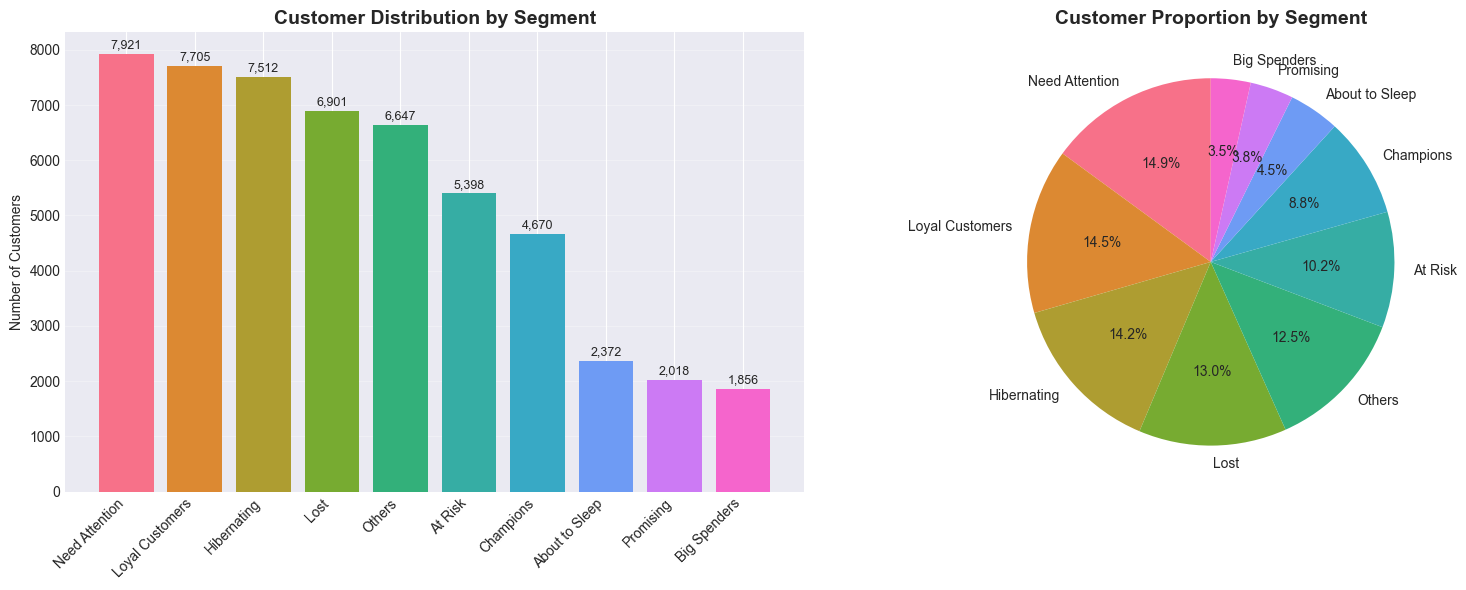

In [27]:
# Customer distribution by segment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
segment_counts_sorted = segment_counts.sort_values(ascending=False)
colors = sns.color_palette('husl', len(segment_counts_sorted))
ax1.bar(range(len(segment_counts_sorted)), segment_counts_sorted.values, color=colors)
ax1.set_xticks(range(len(segment_counts_sorted)))
ax1.set_xticklabels(segment_counts_sorted.index, rotation=45, ha='right')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(segment_counts_sorted.values):
    ax1.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
ax2.pie(segment_counts_sorted.values, labels=segment_counts_sorted.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Customer Proportion by Segment', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

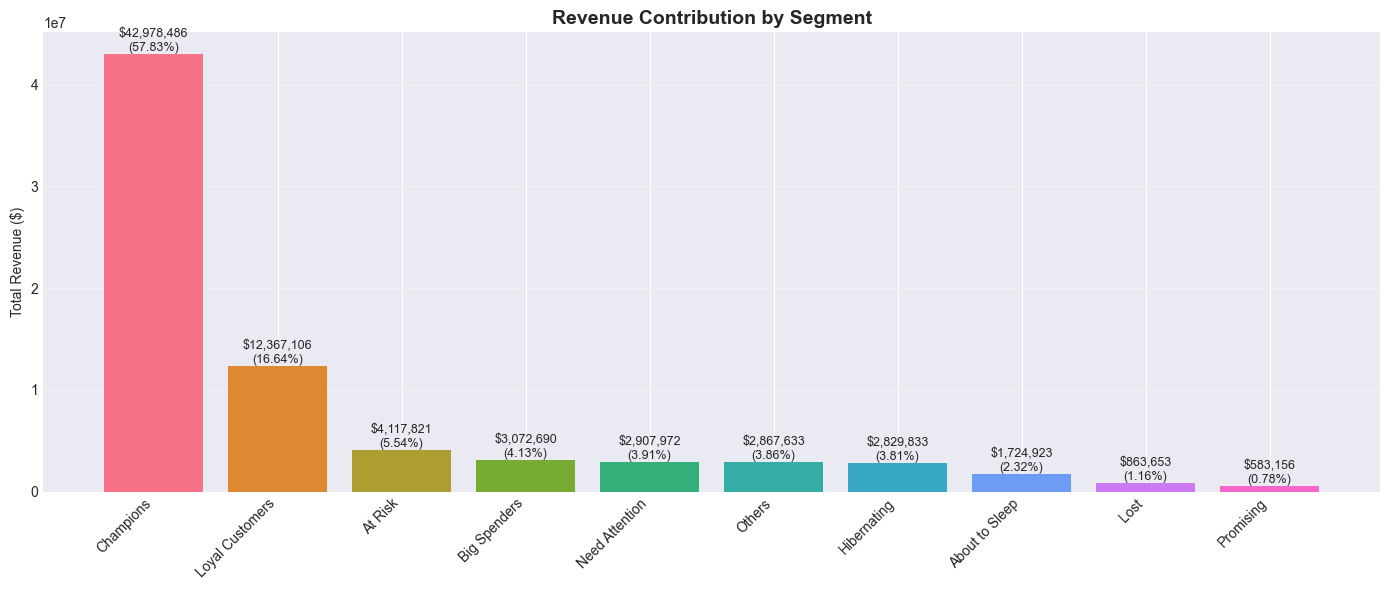

In [28]:
# Revenue contribution by segment
fig, ax = plt.subplots(figsize=(14, 6))

segment_revenue_sorted = segment_revenue.sort_values(ascending=False)
colors = sns.color_palette('husl', len(segment_revenue_sorted))

bars = ax.bar(range(len(segment_revenue_sorted)), segment_revenue_sorted.values, color=colors)
ax.set_xticks(range(len(segment_revenue_sorted)))
ax.set_xticklabels(segment_revenue_sorted.index, rotation=45, ha='right')
ax.set_ylabel('Total Revenue ($)')
ax.set_title('Revenue Contribution by Segment', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels with percentage
for i, (v, pct) in enumerate(zip(segment_revenue_sorted.values, 
                                  segment_revenue_pct[segment_revenue_sorted.index])):
    ax.text(i, v + 1000, f'${v:,.0f}\n({pct}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

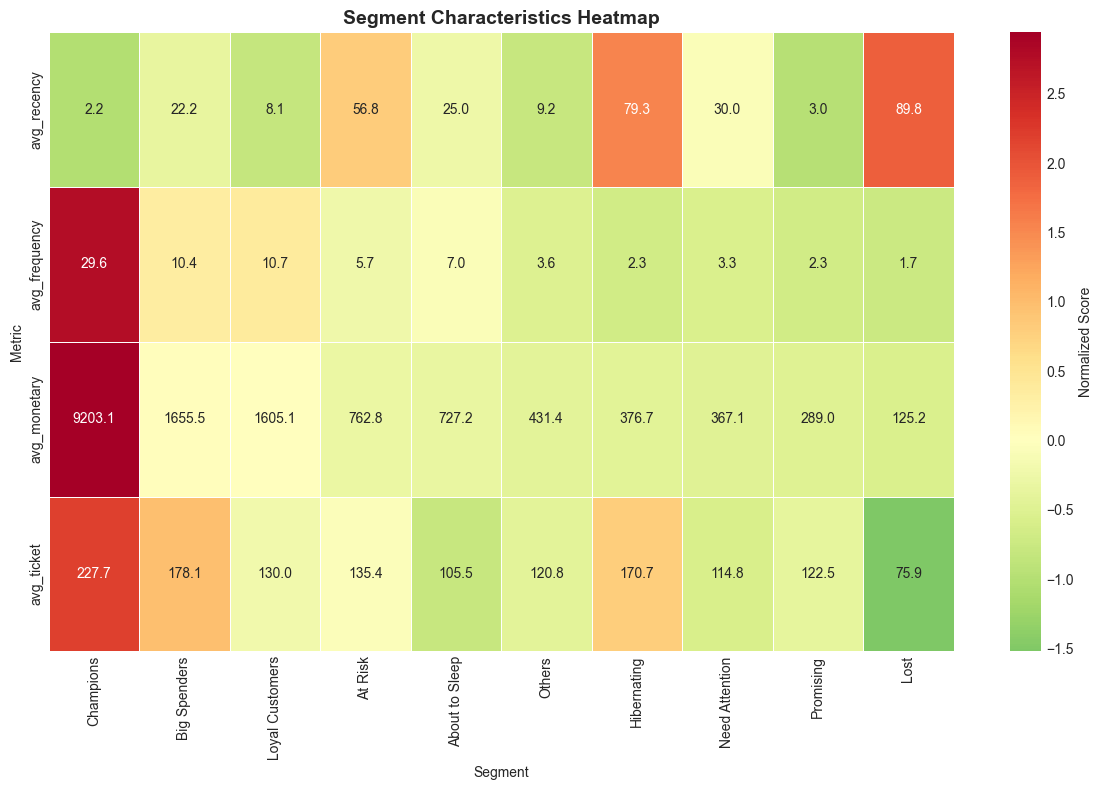

In [29]:
# RFM Segment characteristics - Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data for heatmap
heatmap_data = segment_stats[['avg_recency', 'avg_frequency', 'avg_monetary', 'avg_ticket']].copy()
heatmap_data = heatmap_data.sort_values('avg_monetary', ascending=False)

# Normalize for better visualization
scaler = StandardScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    columns=heatmap_data.columns,
    index=heatmap_data.index
)

sns.heatmap(heatmap_normalized.T, annot=heatmap_data.T.values, fmt='.1f', 
            cmap='RdYlGn_r', center=0, cbar_kws={'label': 'Normalized Score'},
            linewidths=0.5, ax=ax)
ax.set_title('Segment Characteristics Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Metric')

plt.tight_layout()
plt.show()

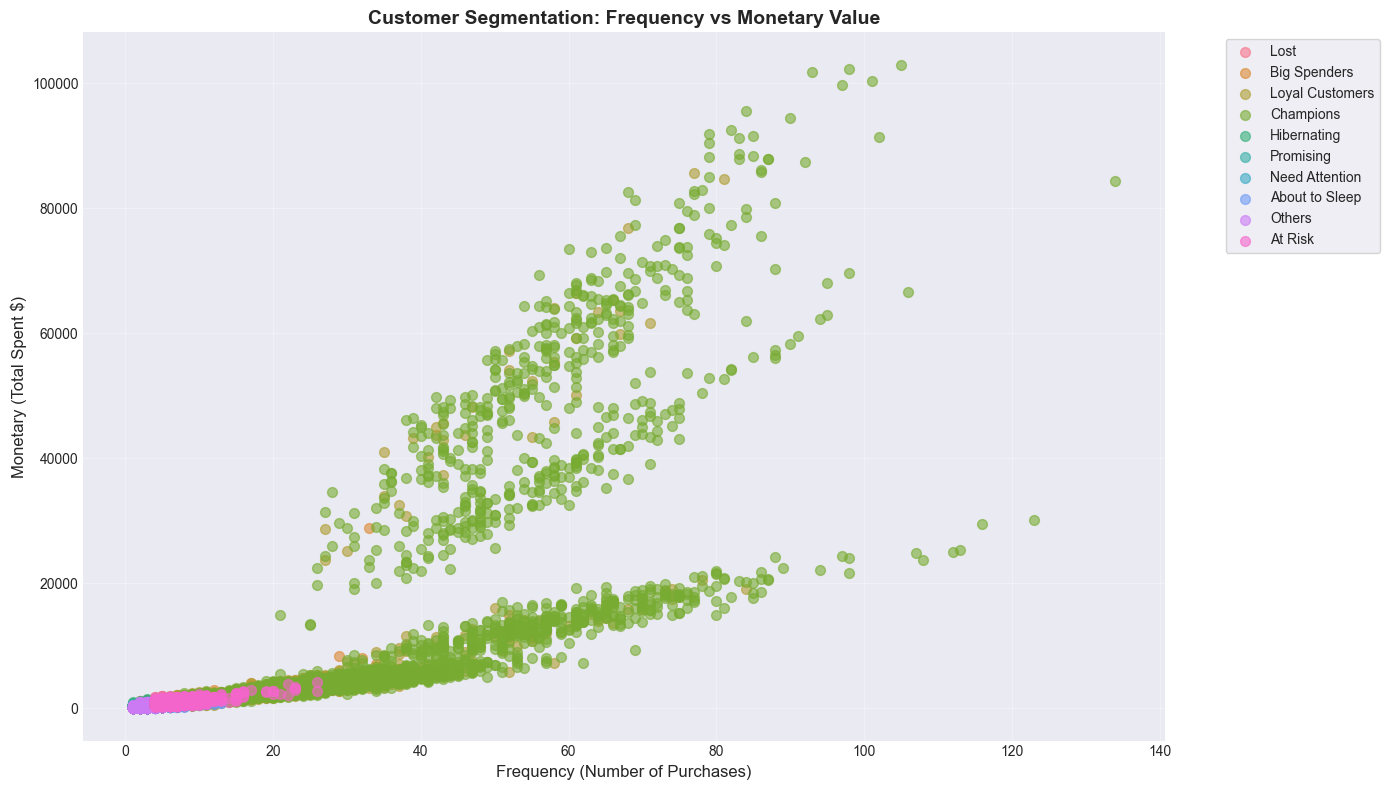

In [30]:
# Scatter plot: Frequency vs Monetary by Segment
fig, ax = plt.subplots(figsize=(14, 8))

segments_unique = rfm['segment'].unique()
colors_map = dict(zip(segments_unique, sns.color_palette('husl', len(segments_unique))))

for segment in segments_unique:
    segment_data = rfm[rfm['segment'] == segment]
    ax.scatter(segment_data['frequency'], segment_data['monetary'], 
               label=segment, alpha=0.6, s=50, color=colors_map[segment])

ax.set_xlabel('Frequency (Number of Purchases)', fontsize=12)
ax.set_ylabel('Monetary (Total Spent $)', fontsize=12)
ax.set_title('Customer Segmentation: Frequency vs Monetary Value', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Segment Profiles & Characteristics

In [31]:
# Segment characteristics and recommendations
segment_profiles = {
    'Champions': {
        'description': 'Best customers - high recency, frequency, and monetary value',
        'characteristics': 'Bought recently, buy often, spend the most',
        'behavior': 'Loyal, engaged, responsive to new products',
        'strategy': 'Reward them, early access to new products, VIP treatment, loyalty programs',
        'priority': 'Critical'
    },
    'Loyal Customers': {
        'description': 'Regular buyers with consistent purchase patterns',
        'characteristics': 'Buy regularly, good spending level, engaged',
        'behavior': 'Consistent, reliable, open to recommendations',
        'strategy': 'Upsell higher value products, cross-sell, personalized recommendations',
        'priority': 'High'
    },
    'Big Spenders': {
        'description': 'High monetary value but may not buy frequently',
        'characteristics': 'High transaction amounts, moderate frequency',
        'behavior': 'Quality-focused, prefer premium products',
        'strategy': 'Premium products, exclusive collections, personalized service',
        'priority': 'High'
    },
    'Promising': {
        'description': 'Recent customers with potential to become loyal',
        'characteristics': 'New or recently active, low frequency',
        'behavior': 'Testing the brand, need nurturing',
        'strategy': 'Onboarding campaigns, engagement programs, build relationship',
        'priority': 'Medium-High'
    },
    'At Risk': {
        'description': 'Were good customers but haven\'t purchased recently',
        'characteristics': 'Previously high value, now disengaged',
        'behavior': 'Losing interest, may churn soon',
        'strategy': 'Win-back campaigns, special offers, re-engagement emails',
        'priority': 'High'
    },
    'About to Sleep': {
        'description': 'Below average recency and frequency',
        'characteristics': 'Declining engagement, moderate past value',
        'behavior': 'Gradually disengaging',
        'strategy': 'Reactivation campaigns, incentives, surveys to understand issues',
        'priority': 'Medium'
    },
    'Need Attention': {
        'description': 'Low recency and frequency, risk of churning',
        'characteristics': 'Infrequent, low engagement',
        'behavior': 'At risk of becoming lost',
        'strategy': 'Targeted offers, product recommendations, limited-time deals',
        'priority': 'Medium'
    },
    'Hibernating': {
        'description': 'Long time since last purchase, low frequency',
        'characteristics': 'Dormant, minimal engagement',
        'behavior': 'Almost lost, need strong incentive',
        'strategy': 'Aggressive discounts, win-back campaigns, last chance offers',
        'priority': 'Low-Medium'
    },
    'Lost': {
        'description': 'Lowest scores across all RFM metrics',
        'characteristics': 'Haven\'t bought in a long time, low value',
        'behavior': 'Churned or never engaged',
        'strategy': 'Deep discounts or exclusion, minimal investment',
        'priority': 'Low'
    },
    'Others': {
        'description': 'Don\'t fit into specific segments',
        'characteristics': 'Mixed behaviors, transitional state',
        'behavior': 'Variable',
        'strategy': 'Monitor and reassign, general campaigns',
        'priority': 'Low'
    }
}

# Create DataFrame from profiles
profiles_df = pd.DataFrame(segment_profiles).T
profiles_df = profiles_df.reset_index()
profiles_df.columns = ['Segment', 'Description', 'Characteristics', 'Behavior', 'Strategy', 'Priority']

# Add stats
profiles_df = profiles_df.merge(segment_stats.reset_index()[['segment', 'customers', 'avg_monetary', 'avg_frequency']], 
                                  left_on='Segment', right_on='segment', how='left').drop('segment', axis=1)

profiles_df = profiles_df.merge(revenue_summary.reset_index()[['segment', 'revenue_pct']], 
                                 left_on='Segment', right_on='segment', how='left').drop('segment', axis=1)

profiles_df = profiles_df[['Segment', 'customers', 'avg_monetary', 'avg_frequency', 'revenue_pct', 
                           'Description', 'Characteristics', 'Behavior', 'Strategy', 'Priority']]

profiles_df.columns = ['Segment', 'Customers', 'Avg Monetary ($)', 'Avg Frequency', 'Revenue %', 
                       'Description', 'Characteristics', 'Behavior', 'Marketing Strategy', 'Priority']

profiles_df = profiles_df.sort_values('Avg Monetary ($)', ascending=False)
profiles_df

,Segment,Customers,Avg Monetary ($),Avg Frequency,Revenue %,Description,Characteristics,Behavior,Marketing Strategy,Priority
0,Champions,4670,9203.10,29.56,57.83,"Best customers - high recency, frequency, and ...","Bought recently, buy often, spend the most","Loyal, engaged, responsive to new products","Reward them, early access to new products, VIP...",Critical
2,Big Spenders,1856,1655.54,10.36,4.13,High monetary value but may not buy frequently,"High transaction amounts, moderate frequency","Quality-focused, prefer premium products","Premium products, exclusive collections, perso...",High
1,Loyal Customers,7705,1605.08,10.67,16.64,Regular buyers with consistent purchase patterns,"Buy regularly, good spending level, engaged","Consistent, reliable, open to recommendations","Upsell higher value products, cross-sell, pers...",High
4,At Risk,5398,762.84,5.73,5.54,Were good customers but haven't purchased rece...,"Previously high value, now disengaged","Losing interest, may churn soon","Win-back campaigns, special offers, re-engagem...",High
5,About to Sleep,2372,727.20,6.95,2.32,Below average recency and frequency,"Declining engagement, moderate past value",Gradually disengaging,"Reactivation campaigns, incentives, surveys to...",Medium
9,Others,6647,431.42,3.60,3.86,Don't fit into specific segments,"Mixed behaviors, transitional state",Variable,"Monitor and reassign, general campaigns",Low
7,Hibernating,7512,376.71,2.34,3.81,"Long time since last purchase, low frequency","Dormant, minimal engagement","Almost lost, need strong incentive","Aggressive discounts, win-back campaigns, last...",Low-Medium
6,Need Attention,7921,367.12,3.28,3.91,"Low recency and frequency, risk of churning","Infrequent, low engagement",At risk of becoming lost,"Targeted offers, product recommendations, limi...",Medium
3,Promising,2018,288.98,2.34,0.78,Recent customers with potential to become loyal,"New or recently active, low frequency","Testing the brand, need nurturing","Onboarding campaigns, engagement programs, bui...",Medium-High
8,Lost,6901,125.15,1.73,1.16,Lowest scores across all RFM metrics,"Haven't bought in a long time, low value",Churned or never engaged,"Deep discounts or exclusion, minimal investment",Low


In [32]:
# Display detailed segment profiles
for idx, row in profiles_df.iterrows():
    print(f"{'='*80}")
    print(f"🎯 {row['Segment'].upper()}")
    print(f"{'='*80}")
    print(f"Customers: {row['Customers']:,} ({row['Revenue %']:.1f}% of revenue)")
    print(f"Avg Monetary: ${row['Avg Monetary ($)']:,.2f}")
    print(f"Avg Frequency: {row['Avg Frequency']:.1f} purchases")
    print(f"\nDescription: {row['Description']}")
    print(f"Characteristics: {row['Characteristics']}")
    print(f"Behavior: {row['Behavior']}")
    print(f"Marketing Strategy: {row['Marketing Strategy']}")
    print(f"Priority: {row['Priority']}")
    print()

🎯 CHAMPIONS
Customers: 4,670 (57.8% of revenue)
Avg Monetary: $9,203.10
Avg Frequency: 29.6 purchases

Description: Best customers - high recency, frequency, and monetary value
Characteristics: Bought recently, buy often, spend the most
Behavior: Loyal, engaged, responsive to new products
Marketing Strategy: Reward them, early access to new products, VIP treatment, loyalty programs
Priority: Critical

🎯 BIG SPENDERS
Customers: 1,856 (4.1% of revenue)
Avg Monetary: $1,655.54
Avg Frequency: 10.4 purchases

Description: High monetary value but may not buy frequently
Characteristics: High transaction amounts, moderate frequency
Behavior: Quality-focused, prefer premium products
Marketing Strategy: Premium products, exclusive collections, personalized service
Priority: High

🎯 LOYAL CUSTOMERS
Customers: 7,705 (16.6% of revenue)
Avg Monetary: $1,605.08
Avg Frequency: 10.7 purchases

Description: Regular buyers with consistent purchase patterns
Characteristics: Buy regularly, good spending le

## 8. Export Segment Data

In [33]:
# Export full RFM table
rfm.to_csv('rfm_customer_segments.csv', index=False)
print("✓ Exported: rfm_customer_segments.csv")

# Export segment summary
segment_summary_export = pd.concat([
    segment_stats.reset_index(),
    revenue_summary.reset_index()[['total_revenue', 'revenue_pct']]
], axis=1)

segment_summary_export.to_csv('segment_summary.csv', index=False)
print("✓ Exported: segment_summary.csv")

# Export segment profiles
profiles_df.to_csv('segment_profiles.csv', index=False)
print("✓ Exported: segment_profiles.csv")

✓ Exported: rfm_customer_segments.csv
✓ Exported: segment_summary.csv
✓ Exported: segment_profiles.csv


## 9. Strategic Segment Exports

In [34]:
# Champions & Loyal Customers (VIP program candidates)
vip_segments = ['Champions', 'Loyal Customers']
vip_customers = rfm[rfm['segment'].isin(vip_segments)]
vip_customers.to_csv('vip_customers.csv', index=False)

print(f"✓ VIP Customers: {len(vip_customers):,} ({len(vip_customers)/len(rfm)*100:.2f}%)")
print(f"  Revenue: ${vip_customers['monetary'].sum():,.2f} ({vip_customers['monetary'].sum()/rfm['monetary'].sum()*100:.2f}%)")

✓ VIP Customers: 12,375 (23.35%)
  Revenue: $55,345,591.96 (74.48%)


In [35]:
# Recovery campaign (At Risk, Hibernating, About to Sleep)
recovery_segments = ['At Risk', 'Hibernating', 'About to Sleep']
recovery_customers = rfm[rfm['segment'].isin(recovery_segments)]

# Sort by monetary value (prioritize high-value customers)
recovery_customers = recovery_customers.sort_values('monetary', ascending=False)
recovery_customers.to_csv('recovery_customers.csv', index=False)

print(f"✓ Recovery Customers: {len(recovery_customers):,} ({len(recovery_customers)/len(rfm)*100:.2f}%)")
print(f"  Revenue at risk: ${recovery_customers['monetary'].sum():,.2f} ({recovery_customers['monetary'].sum()/rfm['monetary'].sum()*100:.2f}%)")

✓ Recovery Customers: 15,282 (28.83%)
  Revenue at risk: $8,672,576.98 (11.67%)


In [36]:
# Promising customers (growth potential)
promising_customers = rfm[rfm['segment'] == 'Promising']
promising_customers.to_csv('promising_customers.csv', index=False)

print(f"✓ Promising Customers: {len(promising_customers):,} ({len(promising_customers)/len(rfm)*100:.2f}%)")
print(f"  Average ticket: ${promising_customers['avg_ticket'].mean():,.2f}")

✓ Promising Customers: 2,018 (3.81%)
  Average ticket: $122.48


## Summary

**RFM Customer Segmentation Analysis Complete**

### Key Outputs:
- **10 Customer Segments** identified with distinct behaviors and values
- **Visual Analytics** showing distribution, revenue contribution, and RFM characteristics
- **Detailed Segment Profiles** with marketing strategies and priorities
- **Exported Datasets** ready for marketing campaigns

### Strategic Focus:
1. **Champions & Loyal Customers**: VIP programs, rewards, premium service
2. **Big Spenders**: Exclusive products, personalized attention
3. **Promising**: Nurturing campaigns, engagement, relationship building
4. **At Risk & Hibernating**: Win-back campaigns, reactivation offers
5. **Lost**: Minimal investment or exclusion

### Files Generated:
- `rfm_customer_segments.csv` - Complete RFM data
- `segment_summary.csv` - Segment statistics
- `segment_profiles.csv` - Detailed segment characteristics
- `vip_customers.csv` - Champions & Loyal customers
- `recovery_customers.csv` - At Risk, Hibernating, About to Sleep
- `promising_customers.csv` - Growth potential customers

**All data ready for actionable marketing campaigns.**